In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv")

df.shape
df.info()
df.head()
df.describe()
df['location'].unique()      # list of countries
df.isnull().sum().sort_values(ascending=False)  # nulls per column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  object 
 1   continent                                   402910 non-null  object 
 2   location                                    429435 non-null  object 
 3   date                                        429435 non-null  object 
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 

weekly_icu_admissions_per_million          418442
weekly_icu_admissions                      418442
excess_mortality_cumulative_per_million    416024
excess_mortality                           416024
excess_mortality_cumulative                416024
                                            ...  
total_deaths                                17631
population                                      0
date                                            0
location                                        0
iso_code                                        0
Length: 67, dtype: int64

In [3]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Drop non-country aggregates like "World", "Asia", "European Union" if present
df = df[~df['location'].isin(['World', 'Asia', 'Europe', 'European Union', 
                                'North America', 'South America', 'Africa', 'Oceania'])]

# Select relevant columns
cols = ['date', 'location', 'total_cases', 'new_cases', 
        'total_deaths', 'new_deaths', 'total_vaccinations']
df = df[cols]

# Handle nulls — forward-fill within each country's time series (cumulative columns),
# fill new_cases/new_deaths with 0
df[['total_cases','total_deaths','total_vaccinations']] = (
    df.groupby('location')[['total_cases','total_deaths','total_vaccinations']]
      .ffill()
)
df['new_cases'] = df['new_cases'].fillna(0)
df['new_deaths'] = df['new_deaths'].fillna(0)

# Drop rows still missing total_cases (no data at all for that country)
df = df.dropna(subset=['total_cases'])

In [4]:
# Top 10 countries by total cases (latest date)
latest = df.sort_values('date').groupby('location').tail(1)
top10 = latest.sort_values('total_cases', ascending=False).head(10)
top10[['location','total_cases','total_deaths']]

,location,total_cases,total_deaths
166872,High-income countries,429044049.0,2997359.0
409811,Upper-middle-income countries,251753518.0,2824452.0
123276,European Union (27),185822587.0,1262988.0
405124,United States,103436829.0,1193165.0
75343,China,99373219.0,122304.0
222800,Lower-middle-income countries,91954400.0,1188026.0
175230,India,45041748.0,533623.0
132040,France,38997490.0,168091.0
142084,Germany,38437756.0,174979.0
51907,Brazil,37511921.0,702116.0


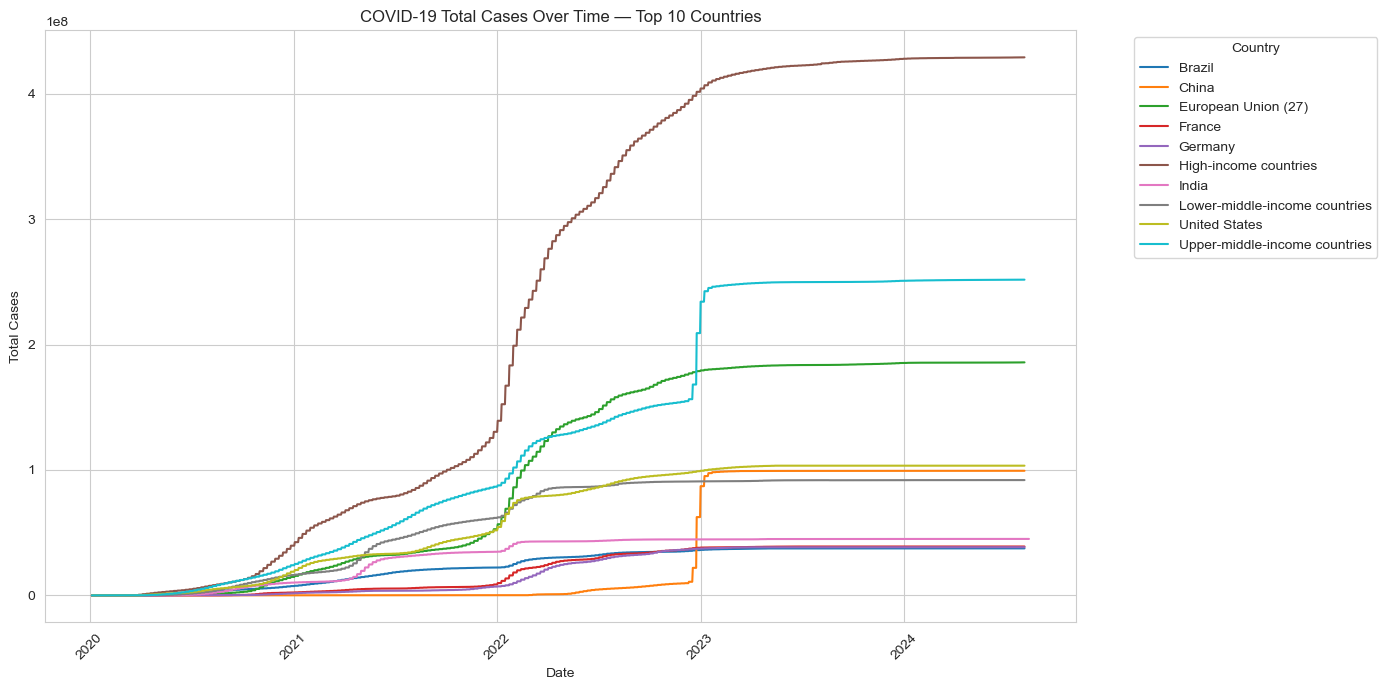

In [5]:
top_countries = top10['location'].tolist()
subset = df[df['location'].isin(top_countries)]

plt.figure(figsize=(14,7))
sns.lineplot(data=subset, x='date', y='total_cases', hue='location')
plt.title('COVID-19 Total Cases Over Time — Top 10 Countries')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.xticks(rotation=45)
plt.legend(title='Country', bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.savefig('cases_over_time.png')
plt.show()

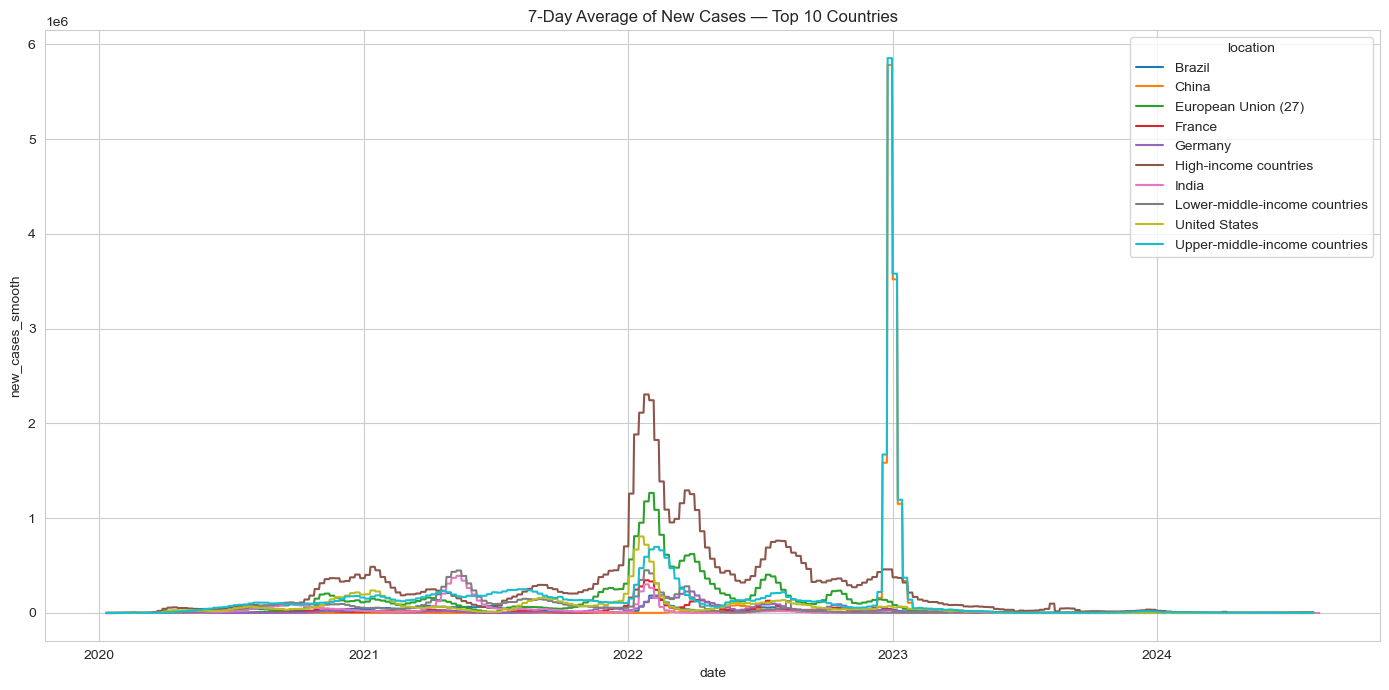

In [6]:
subset = subset.copy()
subset['new_cases_smooth'] = (
    subset.groupby('location')['new_cases']
          .transform(lambda x: x.rolling(7).mean())
)

plt.figure(figsize=(14,7))
sns.lineplot(data=subset, x='date', y='new_cases_smooth', hue='location')
plt.title('7-Day Average of New Cases — Top 10 Countries')
plt.tight_layout()
plt.savefig('7_day_average_new_cases_lineplot.png')
plt.show()

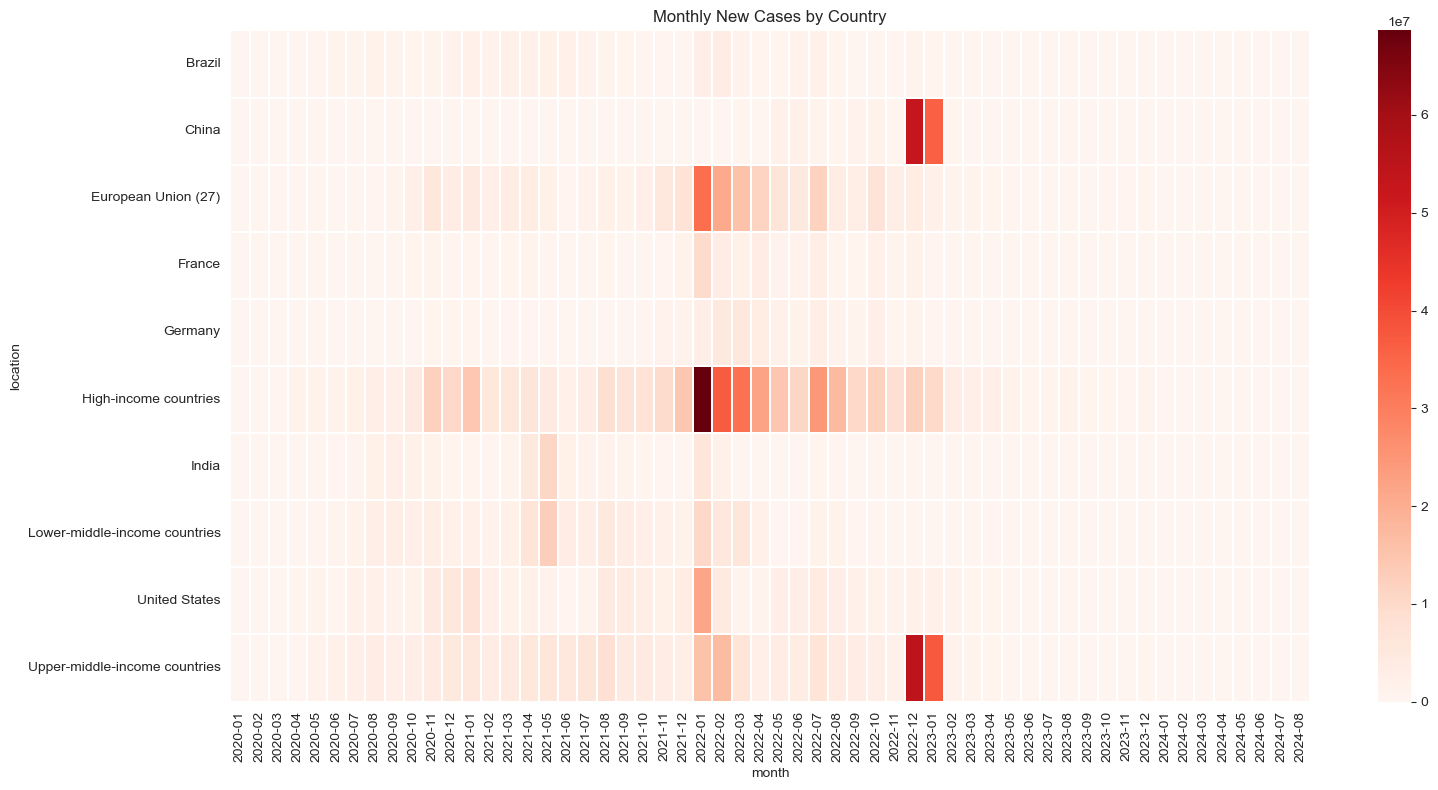

In [7]:
subset['month'] = subset['date'].dt.to_period('M').astype(str)
pivot = subset.pivot_table(index='location', columns='month', 
                             values='new_cases', aggfunc='sum')

plt.figure(figsize=(16,8))
sns.heatmap(pivot, cmap='Reds', linewidths=0.3)
plt.title('Monthly New Cases by Country')
plt.tight_layout()
plt.savefig('monthly_cases_heatmap.png')
plt.show()

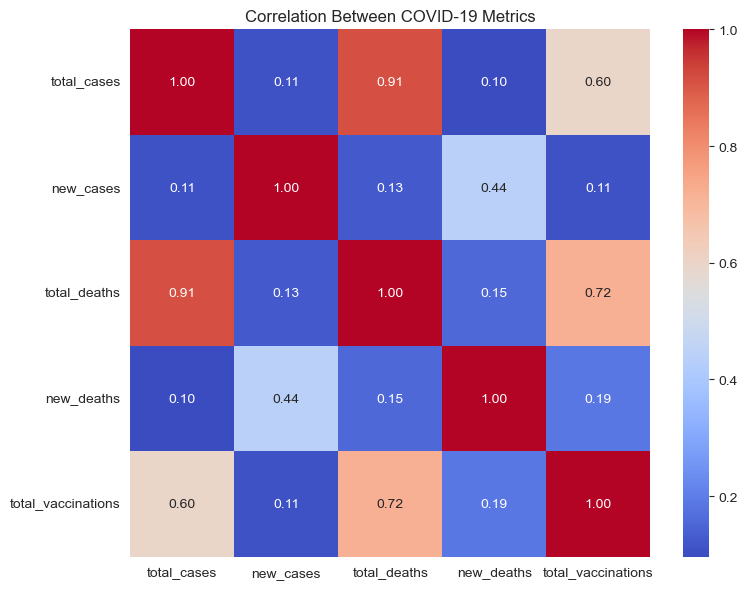

In [8]:
corr_cols = ['total_cases','new_cases','total_deaths','new_deaths','total_vaccinations']
corr = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between COVID-19 Metrics')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

C:\Users\Lakshika\AppData\Local\Temp\ipykernel_19432\3119327719.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest.sort_values('death_rate', ascending=False).head(10),


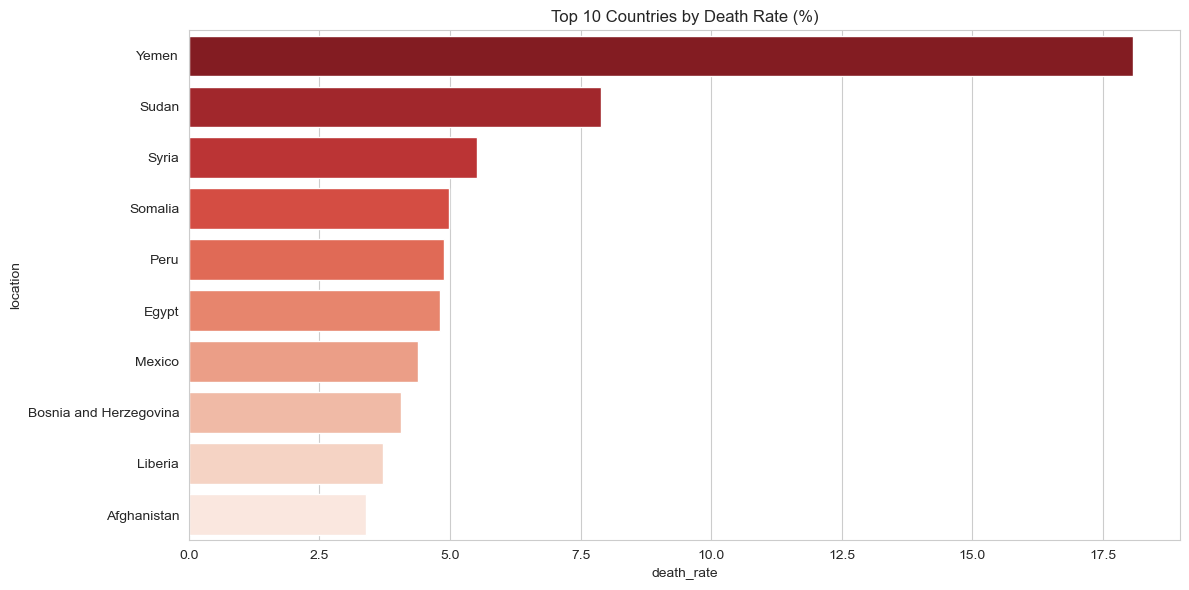

In [9]:
latest['death_rate'] = (latest['total_deaths'] / latest['total_cases']) * 100

plt.figure(figsize=(12,6))
sns.barplot(data=latest.sort_values('death_rate', ascending=False).head(10),
            x='death_rate', y='location', palette='Reds_r')
plt.title('Top 10 Countries by Death Rate (%)')
plt.tight_layout()
plt.savefig('Top10Countries_deathrate_bargraph.png')
plt.show()